# Notebook 22 -- Wu 2003 Data Generation

This notebook is the nb22 checkpoint from
[`../project_wu2003_sbi.md`](../project_wu2003_sbi.md): generate the WU2003
observation windows that downstream summary-statistics and SBI notebooks will
consume.

Plan contract:

- `23` scenarios = `16` closed-loop + `7` open-loop diagnostic counterparts
- `30` replicates per scenario
- `2` information structures: S-A and S-B
- `2 h` observation window at `1 min` resolution = `120` time points
- S-A: `8` channels, with `x_D`
- S-B: `7` channels, without `x_D`

The generated files are:

- [`../data/wu2003_observations.npz`](../data/wu2003_observations.npz)
- [`../data/wu2003_scenario_configs.csv`](../data/wu2003_scenario_configs.csv)


## 1. Imports and generator settings

In [1]:
from pathlib import Path
import time

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cstr_sbi.recycle.simulator import (
    DEFAULT_N_REPLICATES,
    DEFAULT_N_SAVE,
    DEFAULT_SENSOR_NOISE_PCT,
    DEFAULT_T_FINAL_H,
    RAW_CHANNELS,
    SA_CHANNELS,
    SB_CHANNELS,
    generate_dataset,
    physical_effect_metrics,
    save_dataset,
)
from cstr_sbi.recycle.scenarios import list_closed_loop_configs, list_open_loop_configs

print("JAX devices:", jax.devices())
print(f"Closed-loop scenarios: {len(list_closed_loop_configs())}")
print(f"Open-loop diagnostic counterparts: {len(list_open_loop_configs())}")
print(f"Replicates per scenario: {DEFAULT_N_REPLICATES}")
print(f"Window: {DEFAULT_T_FINAL_H} h, time points: {DEFAULT_N_SAVE}")
print(f"Sensor noise fraction: {DEFAULT_SENSOR_NOISE_PCT}")
print("Raw channels:", RAW_CHANNELS)
print("S-A channels:", SA_CHANNELS)
print("S-B channels:", SB_CHANNELS)


JAX devices: [CpuDevice(id=0)]
Closed-loop scenarios: 16
Open-loop diagnostic counterparts: 7
Replicates per scenario: 30
Window: 2.0 h, time points: 120
Sensor noise fraction: 0.003
Raw channels: ['z_A', 'T_r', 'T_j', 'Q_j', 'x_D', 'x_B', 'F_R_norm', 'T_reb', 'Q_reb', 'F_B_norm']
S-A channels: ['T_r', 'T_j', 'Q_j', 'x_D', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm']
S-B channels: ['T_r', 'T_j', 'Q_j', 'T_reb', 'Q_reb', 'F_R_norm', 'F_B_norm']


## 2. Generate the dataset

The generator integrates one deterministic trajectory per scenario and then adds
independent Gaussian sensor noise for each replicate. This is much faster than
solving the ODE 1380 times and is sufficient for nb22 because the current
stochastic layer is intended to represent measurement-window variation, not
process-model uncertainty.


In [2]:
N_REPLICATES = 30
N_SAVE = 120
T_FINAL_H = 2.0
SEED = 20260625
NOISE_PCT = 0.003

start = time.perf_counter()
dataset = generate_dataset(
    n_replicates=N_REPLICATES,
    t_final_h=T_FINAL_H,
    n_save=N_SAVE,
    noise_pct=NOISE_PCT,
    seed=SEED,
)
elapsed = time.perf_counter() - start

obs_sa = dataset["observations_sa"]
obs_sb = dataset["observations_sb"]
labels = dataset["labels"]
scenario_table = dataset["scenario_table"]

print(f"Generation time: {elapsed:.2f} s")
print(f"S-A observations: {obs_sa.shape}")
print(f"S-B observations: {obs_sb.shape}")
print(f"Labels: {labels.shape}")
print(f"Scenario table: {scenario_table.shape}")


Generation time: 1.97 s
S-A observations: (690, 120, 8)
S-B observations: (690, 120, 7)
Labels: (690, 9)
Scenario table: (23, 10)


## 3. Scenario table and replicate counts

In [3]:
display(scenario_table)

count_table = (
    labels.groupby(["mode", "scenario_name"])
    .size()
    .rename("n_windows_per_structure")
    .reset_index()
)
display(count_table)


,id,name,alpha,beta_r,eta_col,xi_reb,z_A0_eff,mode,description,theta
0,1,W1_healthy,1.00,1.00,1.00,1.00,0.90,closed_loop,"Healthy plant, all parameters nominal.","[1.0, 1.0, 1.0, 1.0, 0.8999999761581421]"
1,2,W2_cat_decay,0.65,1.00,1.00,1.00,0.90,closed_loop,Severe catalyst decay (alpha=0.65). Reaction r...,"[0.6499999761581421, 1.0, 1.0, 1.0, 0.89999997..."
2,3,W3_rxr_fouling,1.00,0.65,1.00,1.00,0.90,closed_loop,Severe CSTR jacket fouling (beta_r=0.65). UA r...,"[1.0, 0.6499999761581421, 1.0, 1.0, 0.89999997..."
3,4,W4_col_tray_eff,1.00,1.00,0.70,1.00,0.90,closed_loop,Column tray efficiency loss (eta_col=0.70). Se...,"[1.0, 1.0, 0.699999988079071, 1.0, 0.899999976..."
4,5,W5_reb_starve,1.00,1.00,1.00,0.65,0.90,closed_loop,Reboiler duty reduction (xi_reb=0.65). Under-s...,"[1.0, 1.0, 1.0, 0.6499999761581421, 0.89999997..."
5,6,W6_feed_lean,1.00,1.00,1.00,1.00,0.75,closed_loop,"Feed composition shift lean (z_A0=0.75, A-lean...","[1.0, 1.0, 1.0, 1.0, 0.75]"
6,7,W7_feed_rich,1.00,1.00,1.00,1.00,0.95,closed_loop,"Feed composition shift rich (z_A0=0.95, A-rich...","[1.0, 1.0, 1.0, 1.0, 0.949999988079071]"
7,8,W8_mild_cat,0.80,1.00,1.00,1.00,0.90,closed_loop,Moderate catalyst decay (alpha=0.80). Early-st...,"[0.800000011920929, 1.0, 1.0, 1.0, 0.899999976..."
8,9,W9_mild_fouling,1.00,0.80,1.00,1.00,0.90,closed_loop,Moderate jacket fouling (beta_r=0.80). Early-s...,"[1.0, 0.800000011920929, 1.0, 1.0, 0.899999976..."
9,10,W10_mild_col,1.00,1.00,0.80,1.00,0.90,closed_loop,Moderate column degradation (eta_col=0.80).,"[1.0, 1.0, 0.800000011920929, 1.0, 0.899999976..."


,mode,scenario_name,n_windows_per_structure
0,closed_loop,W10_mild_col,30
1,closed_loop,W11_snowball,30
2,closed_loop,W12_rxr_combined,30
3,closed_loop,W13_col_combined,30
4,closed_loop,W14_feed_cat,30
5,closed_loop,W15_severe_multi,30
6,closed_loop,W16_mild_all,30
7,closed_loop,W1_healthy,30
8,closed_loop,W2_cat_decay,30
9,closed_loop,W3_rxr_fouling,30


## 4. Persist outputs

The `.npz` stores both S-A and S-B arrays plus labels/channel metadata. The CSV
is a human-readable scenario truth table.


In [4]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
npz_path = save_dataset(dataset, data_dir / "wu2003_observations.npz")
csv_path = data_dir / "wu2003_scenario_configs.csv"
scenario_table.to_csv(csv_path, index=False)

print(f"Wrote {npz_path}")
print(f"Wrote {csv_path}")
print(f"NPZ size: {npz_path.stat().st_size / 1024**2:.2f} MiB")


Wrote data/wu2003_observations.npz
Wrote data/wu2003_scenario_configs.csv
NPZ size: 8.74 MiB


## 5. Basic data-quality checks

These checks make sure the dataset is shaped as planned and does not contain
NaNs or infinities. They are deliberately mechanical and should pass before any
physical interpretation is trusted.


In [5]:
expected_scenarios = 23
expected_windows_per_structure = expected_scenarios * N_REPLICATES
expected_total_windows = expected_windows_per_structure * 2

nan_rate_sa = 1.0 - np.isfinite(obs_sa).mean()
nan_rate_sb = 1.0 - np.isfinite(obs_sb).mean()

shape_checks = pd.DataFrame([
    {
        "check": "scenario count",
        "expected": expected_scenarios,
        "observed": len(scenario_table),
        "passes": len(scenario_table) == expected_scenarios,
    },
    {
        "check": "S-A window shape",
        "expected": (expected_windows_per_structure, N_SAVE, len(SA_CHANNELS)),
        "observed": obs_sa.shape,
        "passes": obs_sa.shape == (expected_windows_per_structure, N_SAVE, len(SA_CHANNELS)),
    },
    {
        "check": "S-B window shape",
        "expected": (expected_windows_per_structure, N_SAVE, len(SB_CHANNELS)),
        "observed": obs_sb.shape,
        "passes": obs_sb.shape == (expected_windows_per_structure, N_SAVE, len(SB_CHANNELS)),
    },
    {
        "check": "total windows",
        "expected": expected_total_windows,
        "observed": obs_sa.shape[0] + obs_sb.shape[0],
        "passes": obs_sa.shape[0] + obs_sb.shape[0] == expected_total_windows,
    },
    {
        "check": "S-A finite values",
        "expected": "nan/inf rate = 0",
        "observed": nan_rate_sa,
        "passes": nan_rate_sa == 0.0,
    },
    {
        "check": "S-B finite values",
        "expected": "nan/inf rate = 0",
        "observed": nan_rate_sb,
        "passes": nan_rate_sb == 0.0,
    },
    {
        "check": "S-A includes x_D",
        "expected": True,
        "observed": "x_D" in SA_CHANNELS,
        "passes": "x_D" in SA_CHANNELS,
    },
    {
        "check": "S-B excludes x_D",
        "expected": True,
        "observed": "x_D" not in SB_CHANNELS,
        "passes": "x_D" not in SB_CHANNELS,
    },
])

shape_checks


,check,expected,observed,passes
0,scenario count,23,23,True
1,S-A window shape,"(690, 120, 8)","(690, 120, 8)",True
2,S-B window shape,"(690, 120, 7)","(690, 120, 7)",True
3,total windows,1380,1380,True
4,S-A finite values,nan/inf rate = 0,0.0,True
5,S-B finite values,nan/inf rate = 0,0.0,True
6,S-A includes x_D,True,True,True
7,S-B excludes x_D,True,True,True


## 6. Physical-effect checks

These checks verify that the generated deterministic scenario windows contain
the effects the paper needs:

- **Snowball effect:** catalyst decay increases recycle flow.
- **Masking:** jacket fouling is mostly hidden in `T_r` under feedback.
- **Compensation:** the controller output `Q_j` moves when jacket fouling occurs.
- **Column degradation:** S-A/reboiler channels move under tray-efficiency loss.
- **Open-loop contrast:** open-loop diagnostic windows expose larger temperature
  excursions than closed-loop windows.


In [6]:
effect_checks = physical_effect_metrics(dataset)
effect_checks


,effect,scenario,metric,value,passes
0,snowball onset,W2_cat_decay,F_R change [%],4.012966,True
1,compound snowball,W11_snowball,F_R change [%],3.590930,True
2,masking,W3_rxr_fouling,max |T_r - T_sp| [K],1.092804,True
3,compensation,W3_rxr_fouling,Q_j change [%],58.059345,True
4,column degradation,W4_col_tray_eff,T_reb final shift [K] vs W1,4.276245,True
5,open-loop contrast,W3_rxr_fouling_ol,OL/CL max T excursion ratio,108.817703,True


## 7. Visual inspection: key effects

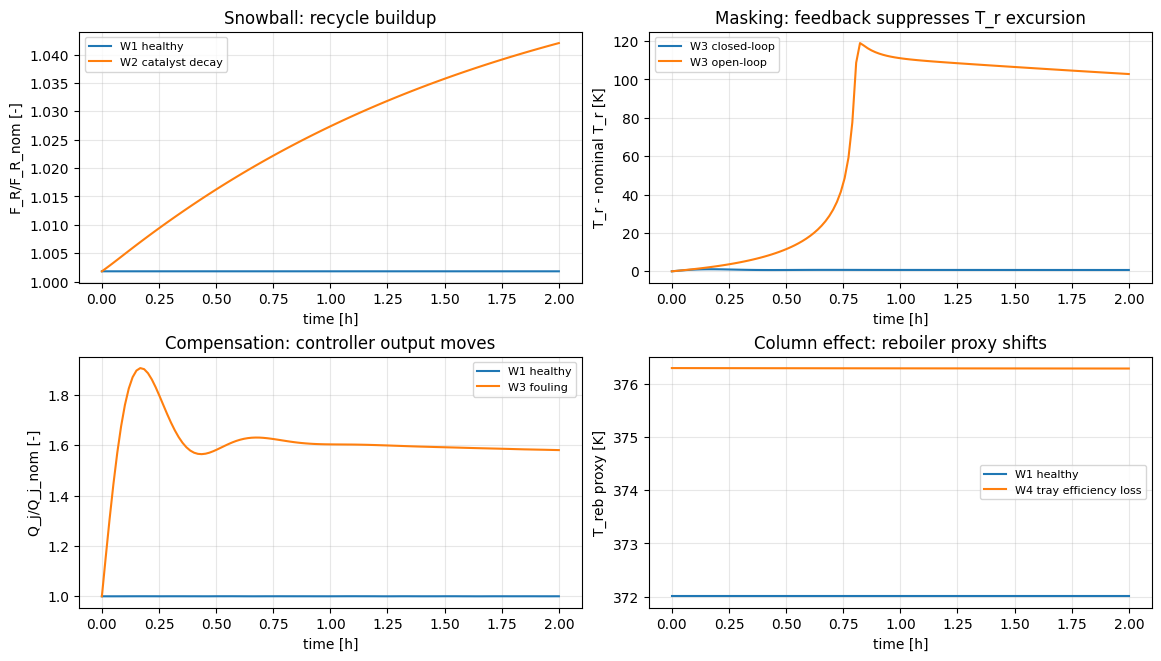

In [7]:
raw = dataset["deterministic_raw"]
raw_idx = {name: i for i, name in enumerate(RAW_CHANNELS)}

def series(scenario, channel):
    return raw[scenario][:, raw_idx[channel]]

t = dataset["t_h"]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.5), constrained_layout=True)

axes[0, 0].plot(t, series("W1_healthy", "F_R_norm"), label="W1 healthy")
axes[0, 0].plot(t, series("W2_cat_decay", "F_R_norm"), label="W2 catalyst decay")
axes[0, 0].set_ylabel("F_R/F_R_nom [-]")
axes[0, 0].set_title("Snowball: recycle buildup")

axes[0, 1].plot(t, series("W3_rxr_fouling", "T_r") - series("W1_healthy", "T_r")[0], label="W3 closed-loop")
axes[0, 1].plot(t, series("W3_rxr_fouling_ol", "T_r") - series("W1_healthy", "T_r")[0], label="W3 open-loop")
axes[0, 1].set_ylabel("T_r - nominal T_r [K]")
axes[0, 1].set_title("Masking: feedback suppresses T_r excursion")

axes[1, 0].plot(t, series("W1_healthy", "Q_j") / series("W1_healthy", "Q_j")[0], label="W1 healthy")
axes[1, 0].plot(t, series("W3_rxr_fouling", "Q_j") / series("W1_healthy", "Q_j")[0], label="W3 fouling")
axes[1, 0].set_ylabel("Q_j/Q_j_nom [-]")
axes[1, 0].set_title("Compensation: controller output moves")

axes[1, 1].plot(t, series("W1_healthy", "T_reb"), label="W1 healthy")
axes[1, 1].plot(t, series("W4_col_tray_eff", "T_reb"), label="W4 tray efficiency loss")
axes[1, 1].set_ylabel("T_reb proxy [K]")
axes[1, 1].set_title("Column effect: reboiler proxy shifts")

for ax in axes.ravel():
    ax.set_xlabel("time [h]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.show()


## 8. Replicate noise sanity check

In [8]:
# Pull W1 S-A replicate block and inspect channel standard deviations.
w1_mask = labels["scenario_name"].to_numpy() == "W1_healthy"
w1_sa = obs_sa[w1_mask]
noise_summary = pd.DataFrame({
    "channel": SA_CHANNELS,
    "mean_overall": w1_sa.mean(axis=(0, 1)),
    "std_overall": w1_sa.std(axis=(0, 1)),
    "mean_replicate_std": w1_sa.std(axis=1).mean(axis=0),
})
noise_summary


,channel,mean_overall,std_overall,mean_replicate_std
0,T_r,3.422750e+02,1.042749,1.037316
1,T_j,3.313359e+02,0.988025,0.981510
2,Q_j,9.492246e+06,28512.230828,28371.004151
3,x_D,9.755340e-01,0.002935,0.002918
4,T_reb,3.720021e+02,1.121478,1.113712
5,Q_reb,1.201178e+07,36142.302799,35911.554691
6,F_R_norm,1.001864e+00,0.002987,0.002964
7,F_B_norm,1.000037e+00,0.003011,0.002991


## 9. Final nb22 acceptance check

In [9]:
acceptance = pd.DataFrame([
    {
        "check": "mechanical data contract",
        "expected": "all shape/finite/channel checks pass",
        "observed": bool(shape_checks["passes"].all()),
        "status": "PASS" if bool(shape_checks["passes"].all()) else "FAIL",
    },
    {
        "check": "physical effects present",
        "expected": "snowball, masking, compensation, column, open-loop checks pass",
        "observed": bool(effect_checks["passes"].all()),
        "status": "PASS" if bool(effect_checks["passes"].all()) else "FAIL",
    },
    {
        "check": "saved npz exists",
        "expected": str(npz_path),
        "observed": npz_path.exists(),
        "status": "PASS" if npz_path.exists() else "FAIL",
    },
    {
        "check": "saved scenario csv exists",
        "expected": str(csv_path),
        "observed": csv_path.exists(),
        "status": "PASS" if csv_path.exists() else "FAIL",
    },
])
acceptance


,check,expected,observed,status
0,mechanical data contract,all shape/finite/channel checks pass,True,PASS
1,physical effects present,"snowball, masking, compensation, column, open-...",True,PASS
2,saved npz exists,data/wu2003_observations.npz,True,PASS
3,saved scenario csv exists,data/wu2003_scenario_configs.csv,True,PASS


## 10. Interpretation

The generated nb22 dataset satisfies the current plan-level data contract:
`23` scenarios, `30` replicates, `2` structures, and the planned `8`/`7` channel
asymmetry between S-A and S-B.

The important physical effects are visible in the deterministic windows before
sensor noise is added. That matters because downstream summary statistics and
SBI training should learn from the intended process signatures rather than from
accidental artefacts of the data generator.

Remaining limitation before publication-grade data generation: the current
S-A/S-B split is still an information-structure split over a shared plant model.
Full Wu S-A/S-B controller dynamics would require explicit reflux-ratio and
reboiler loops. The current dataset is suitable for nb23 summary-statistics
prototyping and for checking whether the planned signatures are separable.
